# DEEPMLP (flax nnx) -- profile (F) weight recovery for DE_loopV1's ProtocolV2

Same building blocks as [MLP_Merlin.ipynb](../MLP_Merlin.ipynb)'s `SimpleMLP` (`nnx.Linear` +
`nnx.BatchNorm` + `nnx.Dropout` + `nnx.gelu`, `nnx.Optimizer` + `optax.adamw`, a warmup-cosine
LR schedule, `train_step`-style functions), wired up end-to-end to the same profile-recovery
problem as [CLAUDE/test_profile_mlp_CLAUDE.ipynb](CLAUDE/test_profile_mlp_CLAUDE.ipynb) -- i.e.
[CLAUDE/MLP_regreesionCLAUDE.py](CLAUDE/MLP_regreesionCLAUDE.py) re-implemented in JAX/flax nnx
instead of torch.

`ProfileMLP`'s input is the one-hot encoded 7-position sequence (each position expanded into a
length-20 one-hot vector, `input_dim=L*A=140`, no explicit pairwise features) -- it has to
discover any pairwise structure itself from those per-position one-hot blocks. Same toy library /
`ProtocolV2` setup as [../DE_loopV1.ipynb](../DE_loopV1.ipynb)'s "smallN" Ridge test (`N=2000`,
`n_rounds=1`), so this is directly comparable to both the Ridge and torch-MLP recoveries on the
exact same protocol.

Note on `MLP_Merlin.ipynb`'s last cell: it sketches `SimpleMLP(7, 256, 140, ...)` as if the
target were the 140 profile weights themselves. A real NGS experiment never observes that --
only a scalar log-enrichment-ratio per sequence. `ProfileMLP` below outputs that scalar instead;
F and the effective pairwise J get recovered afterwards (see section 6) from the trained
network's behavior, not read off its input features.

### 0. Setup

In [1]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/", one level below
# sequence_classesV1.py / analysisV1.py / RegressionV1.py -- add the parent dir so their
# sibling imports resolve too (same convention as CLAUDE/test_profile_mlp_CLAUDE.ipynb).
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from flax import nnx
from functools import partial
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import ProtocolV2, initialize_random_weights
from analysisV1 import pearson, precision_at_k, plot_teacher_vs_student, plot_score_teacher_vs_student, plot_topk_recovery_heatmap
import RegressionV1 as reg

print(f"JAX backend : {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend : gpu -- devices: [CudaDevice(id=0)]


## 1. Toy library

Same shape as `DE_loopV1.ipynb`'s "smallN" Ridge test (`N=2000`, `n_rounds=1`), so `ProfileMLP`,
Ridge and the torch `ProfileMLP` are all being compared on the exact same protocol.


In [2]:
key = jax.random.key(0)
key, k_weights = jax.random.split(key)
# sparsity_J=0.95 -- 95% of the pairwise J couplings are zeroed out at random (biologically
# realistic: most position/amino-acid pairs don't actually interact), which also shrinks J's
# overall contribution to compute_score, keeping the simulation's score range/memory usage
# more controlled if you scale up the number of variants.
F_viab, F_sel, J_viab, J_sel = initialize_random_weights(k_weights, sparsity_J=0.95)

N = 200_000

# 5 independent protocols, defined explicitly (NOT in a loop) so each can be edited on its own
# -- e.g. different noise/T/N per protocol -- while sharing the SAME F/J teacher weights.
# Sharing F/J is required: training/comparing across protocols with DIFFERENT F/J would leave
# no single consistent function for the model to learn.
key, k_seq1 = jax.random.split(key)
sequences_1 = jax.random.randint(k_seq1, shape=(N, 7), minval=0, maxval=20)
protocol_1 = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences_1, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.5, T_sel=0.5, T_viab=0.5,
)

key, k_seq2 = jax.random.split(key)
sequences_2 = jax.random.randint(k_seq2, shape=(N, 7), minval=0, maxval=20)
protocol_2 = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences_2, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.5, T_sel=0.5, T_viab=0.5,
)

key, k_seq3 = jax.random.split(key)
sequences_3 = jax.random.randint(k_seq3, shape=(N, 7), minval=0, maxval=20)
protocol_3 = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences_3, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.5, T_sel=0.5, T_viab=0.5,
)

key, k_seq4 = jax.random.split(key)
sequences_4 = jax.random.randint(k_seq4, shape=(N, 7), minval=0, maxval=20)
protocol_4 = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences_4, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.5, T_sel=0.5, T_viab=0.5,
)

key, k_seq5 = jax.random.split(key)
sequences_5 = jax.random.randint(k_seq5, shape=(N, 7), minval=0, maxval=20)
protocol_5 = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences_5, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.5, T_sel=0.5, T_viab=0.5,
)

# Convenience handle for later loops (evaluation/backgrounds only) -- each protocol_i above
# remains its own independent variable you can edit by hand.
protocols = [protocol_1, protocol_2, protocol_3, protocol_4, protocol_5]
protocol  = protocol_1  # canonical reference -- F_viab/J_viab/F_sel/J_sel/T_viab/T_sel are
                         # identical (same arrays) across every protocol_i.

print("protocol_1..protocol_5 created, shared F/J teacher weights")
print(f"J_viab nonzero entries: {int((J_viab != 0).sum())} / {J_viab.size} ({100*(J_viab != 0).mean():.1f}%)")
print("protocol_1.sequence shape:", protocol_1.sequence.shape)


protocol_1..protocol_5 created, shared F/J teacher weights
J_viab nonzero entries: 758 / 19600 (3.9%)
protocol_1.sequence shape: (200000, 7)


## 2. One-hot per-position sequence encoding + pooled multi-round NGS dataset

`RegressionV1.build_multi_round_dataset` already builds the pooled (sequence, log-ratio) pairs
from `protocol`'s observable NGS reads only (`lambda0p`/`lambda2p`/`lambda3p`) -- reused as-is.
`build_profile_features` below then one-hot encodes each of the 7 raw amino-acid indices
(`seqs_viab[n]`, values in `{0,...,19}`) into a length-20 vector, giving `ProfileMLP` a
`(N, L*A) = (N, 140)` input, alongside 1 log-enrichment target (`y_viab[n]`, roughly
`log(lambda2p/lambda0p)` for that sequence at that step). This is the same single-site one-hot
block as `RegressionV1.build_potts_features`'s design matrix for the Ridge baseline, minus its
pairwise outer-product block -- `ProfileMLP` still has to learn any pairwise structure itself.

In [3]:
L = 7   # num_positions
A = 20  # num_amino_acids

def one_hot_encode(seqs, L=L, A=A):
    """
    (..., L) integer indices in {0, ..., A-1} -> (..., L*A) float32 one-hot, per-position
    blocks flattened. Shared by build_profile_features (training data) and
    extract_effective_FJ's mutant scan, so both feed ProfileMLP the exact same encoding it
    was trained on.
    """
    seqs = np.asarray(seqs).astype(np.int32)
    return np.eye(A, dtype=np.float32)[seqs].reshape(*seqs.shape[:-1], L * A)

def build_profile_features(seqs_obs):
    """
    One-hot per-position amino-acid encoding -- the (L*A,) input to ProfileMLP. seqs_obs[n, p]
    in {0, ..., A-1} is expanded into a length-A one-hot vector per position and flattened, so
    ProfileMLP is L*A=140 numbers in, 1 log-enrichment score out.
    """
    return one_hot_encode(seqs_obs)  # (N, L*A)

# One dataset per protocol, kept SEPARATE (not pooled) -- section 5 below runs two different
# experiments on these: (A) one independent model per protocol, (B) one model retrained
# sequentially across all 5 in turn.
seqs_viab_1, y_viab_1, seqs_sel_1, y_sel_1 = reg.build_multi_round_dataset(protocol_1, n_rounds=1)
seqs_viab_2, y_viab_2, seqs_sel_2, y_sel_2 = reg.build_multi_round_dataset(protocol_2, n_rounds=1)
seqs_viab_3, y_viab_3, seqs_sel_3, y_sel_3 = reg.build_multi_round_dataset(protocol_3, n_rounds=1)
seqs_viab_4, y_viab_4, seqs_sel_4, y_sel_4 = reg.build_multi_round_dataset(protocol_4, n_rounds=1)
seqs_viab_5, y_viab_5, seqs_sel_5, y_sel_5 = reg.build_multi_round_dataset(protocol_5, n_rounds=1)

datasets = [
    (seqs_viab_1, y_viab_1, seqs_sel_1, y_sel_1),
    (seqs_viab_2, y_viab_2, seqs_sel_2, y_sel_2),
    (seqs_viab_3, y_viab_3, seqs_sel_3, y_sel_3),
    (seqs_viab_4, y_viab_4, seqs_sel_4, y_sel_4),
    (seqs_viab_5, y_viab_5, seqs_sel_5, y_sel_5),
]

for i, (sv, yv, ss, ys) in enumerate(datasets, start=1):
    print(f"Protocol {i} -- viability: {sv.shape[0]:>7} pairs   selectivity: {ss.shape[0]:>7} pairs")

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]
                                                           

Protocol 1 -- viability:  200000 pairs   selectivity:  112195 pairs
Protocol 2 -- viability:  200000 pairs   selectivity:  112163 pairs
Protocol 3 -- viability:  200000 pairs   selectivity:  112476 pairs
Protocol 4 -- viability:  200000 pairs   selectivity:  112208 pairs
Protocol 5 -- viability:  200000 pairs   selectivity:  112809 pairs


### 2b. Lambda pool evolution through the DE loop

Standalone illustrative run of `protocol.N_loop_DE` (same idea as `DE_loopV1.ipynb`'s single
`loop_DE()` sanity-check cell), tabulating every checkpoint in true pipeline order --
`lambda0 -> lambda0p -> lambda1 -> lambda2 -> lambda2p -> lambda3 -> lambda3p -> lambda4` -- so
the population collapse behind the `Viability`/`Selectivity` row-count gap printed above is
visible stage by stage. This re-runs the DE simulation from scratch (a fresh random draw,
independent of `seqs_viab`/`seqs_sel` built above), so treat it as a diagnostic, not the actual
training data.


In [4]:
import pandas as pd

def lambda_evolution_table(protocol, n_rounds=1):
    """
    Runs protocol.N_loop_DE(n_rounds) and tabulates total abundance + surviving diversity for
    every lambda checkpoint, in true pipeline order, one column group per round.
    """
    rounds = protocol.N_loop_DE(n_rounds)
    stages = ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]

    rows = []
    for round_idx, (bio_row, ngs_row) in enumerate(rounds):
        lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
        lambda0p, lambda2p, lambda3p = ngs_row
        stage_arrays = {
            "lambda0": lambda0, "lambda0p": lambda0p, "lambda1": lambda1,
            "lambda2": lambda2, "lambda2p": lambda2p, "lambda3": lambda3,
            "lambda3p": lambda3p, "lambda4": lambda4,
        }
        for stage in stages:
            arr = np.asarray(stage_arrays[stage])
            rows.append(dict(
                round=round_idx, stage=stage,
                total=float(arr.sum()), n_surviving=int((arr > 0).sum()),
            ))

    df = pd.DataFrame(rows)
    df["pct_surviving"] = 100 * df["n_surviving"] / protocol.d0
    return df.pivot(index="stage", columns="round", values=["total", "n_surviving", "pct_surviving"]).reindex(stages)

lambda_evolution_table(protocol, n_rounds=1)


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s]


,total,n_surviving,pct_surviving
round,0,0,0
stage,,,
lambda0,1.000000e+09,200000.0,100.0000
lambda0p,1.000707e+09,200000.0,100.0000
lambda1,4.999779e+08,200000.0,100.0000
lambda2,6.533333e+12,180217.0,90.1085
lambda2p,9.967103e+08,112146.0,56.0730
lambda3,2.721396e+12,164478.0,82.2390
lambda3p,9.993173e+08,89258.0,44.6290
lambda4,1.000002e+09,89949.0,44.9745


### 2c. Top-k recovery heatmap across (N1, rho)

Sweeps `protocol`'s `N1` (plasmid molecules sampled per round) and `_rho` (HEK cells
transfected per plasmid) around their current values from section 1, and measures -- for
every combination, averaged over a few stochastic repeats -- how well the sequences that end
up most abundant after one DE round (`lambda4`) match the sequences that are truly best by the
combined viability + selectivity score. See `plot_topk_recovery_heatmap`'s docstring in
`analysisV1.py` for the full step-by-step explanation; in short, brighter cells mean a gentler
population bottleneck (more of the true top sequences survive), darker cells mean a harsher one.
The protocol's actual (N1, rho) is marked with a red star, and the white contour lines are
isolines of `mu = rho * N1 / d0` (expected HEK cells transfected per plasmid, averaged across
the library) -- the single combined quantity that mostly drives how harsh the bottleneck is.

This only mutates `protocol.N1` / `protocol._rho` (and the lambda* pool attributes) for the
duration of the sweep and restores them afterward, so it's safe to run before the training
cells below -- but it IS expensive (`len(N1_sweep) * len(rho_sweep) * n_repeats` full DE
rounds), so the grid below is kept small (5x5, 3 repeats) for a quick look.


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


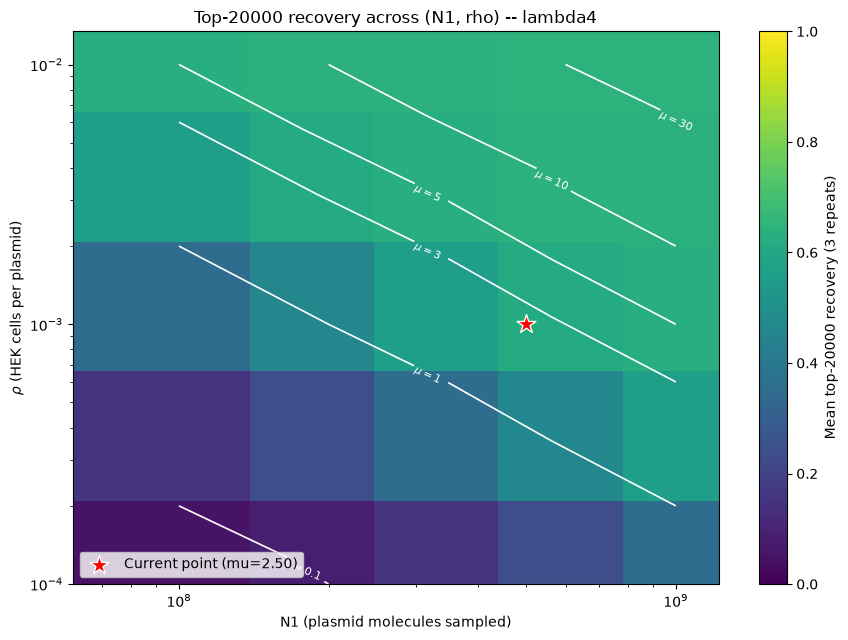

In [5]:
# Centered on protocol's actual N1=5e8 / rho=1e-3 (mu = rho*N1/d0 = 1e-3*5e8/200_000 = 2.5)
N1_sweep  = np.geomspace(1e8, 1e9, 5)
rho_sweep = np.geomspace(1e-4, 1e-2, 5)

fig, mean_recovery, std_recovery = plot_topk_recovery_heatmap(
    protocol, N1_values=N1_sweep, rho_values=rho_sweep,
    k_frac=0.10, n_repeats=3, n_rounds=1,
)


## 3. ProfileMLP

Same building blocks as `SimpleMLP` in `MLP_Merlin.ipynb` (Linear + BatchNorm + Dropout + gelu),
stacked twice for more capacity and extended with a `train` flag so BatchNorm/Dropout can switch
to eval mode -- `SimpleMLP`'s sketch never needed that since it was never actually run at
inference. Input is the one-hot encoded sequence (`input_dim=L*A=140`, each position a length-20
one-hot block); output is a single score (the log-ratio prediction for one sequence), not the
underlying F/J weights directly -- those get recovered afterwards by probing the trained
network (section 6), the same trick used by `MLP_regreesionCLAUDE.py`'s torch version.

In [6]:
class DEEP_MLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids ->
    input_dim=L*A=140, no raw ordinal indices) -> scalar score. Same building blocks as
    SimpleMLP (Linear + BatchNorm + Dropout + gelu). Each position's one-hot slice keys
    directly into that position's per-amino-acid effect, so the network no longer has to
    disentangle amino-acid identity from a raw index -- it still has to learn any pairwise
    coupling itself, since only single-site (not pairwise) features are provided.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int, int, int] = (512, 256, 128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2, h3, h4 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, h3, rngs=rngs)
        self.batchnorm3 = nnx.BatchNorm(h3, use_running_average=False, rngs=rngs)
        self.dropout3   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear4    = nnx.Linear(h3, h4, rngs=rngs)
        self.batchnorm4 = nnx.BatchNorm(h4, use_running_average=False, rngs=rngs)
        self.dropout4   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear5    = nnx.Linear(h4, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear3(x)
        x = self.batchnorm3(x, use_running_average=not train)
        x = self.dropout3(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        
        x = self.linear4(x)
        x = self.batchnorm4(x, use_running_average=not train)
        x = self.dropout4(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        
        return self.linear5(x).squeeze(-1)

### Train/eval steps + auto-adjustable LR (same recipe as MLP_Merlin.ipynb)

In [7]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L) raw per-position amino-acid indices
    y : (batch,) pooled log-ratio target (viability or selectivity)
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """
    xb/yb : (steps_per_epoch, batch, ...) -- one epoch's mini-batches, pre-sliced by the
    caller. Fuses the whole epoch's train_step calls into a single compiled nnx.scan instead
    of a Python for-loop issuing steps_per_epoch separate dispatches -- same train_step, same
    per-step math and RNG-stream advancement, just one XLA program per epoch instead of
    hundreds of small ones (verified to reproduce the Python-loop version's losses exactly;
    dispatch overhead, not compute, was what made mini-batch training on GPU slow).
    """
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

## 4. Training loop

Mini-batch SGD with the `optax.warmup_cosine_decay_schedule` from `MLP_Merlin.ipynb`, plus
early stopping on validation MSE -- `MLP_regreesionCLAUDE.py`'s torch recipe, ported to nnx:
best-val state is snapshotted with `nnx.state` and restored with `nnx.update` instead of a
torch `state_dict`.


In [8]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(512, 256, 128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=3, seed=0, verbose=True, model=None):
    """
    model : optional existing DEEP_MLP to continue training from (warm start) instead of
    initializing a fresh one -- used by the section 5B sequential-retraining experiment to
    carry weights across protocols. The optimizer (Adam moments + its own warmup-cosine LR
    schedule sized to THIS call's epochs/steps_per_epoch) is always created fresh, even when
    warm-starting from an existing model.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = DEEP_MLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                          dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    # X_train/y_train live on-device for the whole training loop (DGX Spark's unified memory
    # comfortably fits these sizes) -- only the per-batch index array changes each step, so
    # there's no host<->device transfer inside the epoch loop, just the mini-batch gather.
    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val    = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        # One compiled nnx.scan call runs all steps_per_epoch mini-batch updates -- same
        # train_step, same math as a Python for-loop over batches, just fused into a single
        # XLA program (see train_epoch_scan).
        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

### F/J recovery + diagnostics (moved up from the old sections 6/8b so both 5A and 5B can call them right after training)

`extract_effective_FJ` scans single-/double-mutants against a batch of `backgrounds` -- real
sequences drawn from the pooled protocol population -- and averages every mutant's score shift
over all of them, centering by the mean of the whole probed pool instead of subtracting any one
fixed reference. This is the same recipe as before, just relocated earlier in the notebook.

`shrinkage_diagnostic` reports Pearson r (ranking), the fitted slope of hat~gt (amplitude
attenuation), and std(hat)/std(gt) (the same shrinkage as a plain ratio) -- a good r can look
fine even when the model badly underestimates the true score's spread.

In [9]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


def extract_effective_FJ(model, T, backgrounds, L=L, A=A, batch_size=8192):
    """
    Single- and double-mutant scan against real background sequences.

    For a background s and mutation p->a, M(s^{p->a}) - M(s) isolates f_p(a) only up to terms
    that depend on s's other positions. Averaged over backgrounds with i.i.d.-uniform amino
    acids, those extra terms turn into position-pair averages that don't depend on which
    backgrounds got sampled -- so what's recovered for J is the zero-sum-gauge pairwise
    coupling (row/column means already subtracted out), the same gauge convention used for
    Potts/DCA models of real protein families. F and J recovered this way reproduce
    protocol.compute_score up to a global additive constant.

    backgrounds : (M, L) real sequences, e.g. a random subsample pooled across protocols.
    Mutants are generated here as raw per-position amino-acid indices (easier to construct
    than one-hot directly); one_hot_encode converts each batch to ProfileMLP's actual input
    right before scoring.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.float32)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)

    scores_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk = jnp.asarray(one_hot_encode(x_all[start : start + batch_size], L=L, A=A))
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score = scores.mean()

    single_scores = scores[M : M + n_single].reshape(M, L, A)
    double_scores = scores[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = (F_flat * T).T.astype(np.float32)         # (A, L)

    double_avg = double_scores.mean(axis=0)
    J_hat = np.zeros((L, L, A, A), dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij = double_avg[k] - mean_score - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij * T
        J_hat[j, i] = (delta_ij * T).T

    return F_hat, J_hat


def shrinkage_diagnostic(name, gt, hat):
    """r (ranking), slope(hat~gt) and std(hat)/std(gt) (amplitude attenuation)."""
    slope, intercept = np.polyfit(gt, hat, 1)
    std_ratio = np.std(hat) / np.std(gt)
    r = pearson(gt, hat)
    print(f"{name:20s}  r={r:.3f}  slope(hat~gt)={slope:.3f}  std(hat)/std(gt)={std_ratio:.3f}")
    return r, slope, std_ratio


def plot_precision_at_k(combined_gt, combined_hat, k_fracs=None, highlight_k=0.10, title="Recovery precision@k"):
    if k_fracs is None:
        k_fracs = np.linspace(0.01, 0.5, 25)
    precisions = [precision_at_k(combined_gt, combined_hat, k_frac=k) for k in k_fracs]
    p_highlight = precision_at_k(combined_gt, combined_hat, k_frac=highlight_k)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.array(k_fracs) * 100, precisions, '-o', ms=3, color='tab:blue')
    ax.axvline(highlight_k * 100, color='tab:red', linestyle='--', alpha=0.4)
    ax.scatter([highlight_k * 100], [p_highlight], color='tab:red', zorder=5,
               label=f"top {highlight_k*100:.0f}% : precision={p_highlight:.3f}")
    ax.set_xlabel("Top-k% (ranked by ground-truth combined score)")
    ax.set_ylabel("Precision@k")
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


# Backgrounds pooled across all 5 protocols for the mutant scan.
rng_bg          = np.random.default_rng(0)
M_backgrounds   = 256
all_sequences   = np.concatenate([np.asarray(p.sequence) for p in protocols], axis=0)
bg_idx          = rng_bg.choice(all_sequences.shape[0], size=M_backgrounds, replace=False)
backgrounds     = all_sequences[bg_idx]

score_viab_gt = np.array(protocol.compute_score(protocol.F_viab, protocol.J_viab))
score_sel_gt  = np.array(protocol.compute_score(protocol.F_sel,  protocol.J_sel))

## 5. Two ways to use 5 protocols

- **5A. Independent models**: train a completely separate model per protocol (from scratch,
  same recipe/hyperparameters each time), then average their recovered F_hat/J_hat into an
  ensemble estimate.
- **5B. Sequential retraining**: ONE model, trained on protocol_1's data, then continued (same
  weights, fresh optimizer) on protocol_2's data, ..., through protocol_5 -- the model sees all
  5 datasets in turn instead of being averaged after the fact.

### 5A. Independent models -- one trained from scratch per protocol

In [10]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

models_viab_A, models_sel_A = [], []
for i, (sv, yv, ss, ys) in enumerate(datasets, start=1):
    Xv, Xs = build_profile_features(sv), build_profile_features(ss)
    Xtr_v, ytr_v, Xva_v, yva_v = split_train_val(Xv, yv)
    Xtr_s, ytr_s, Xva_s, yva_s = split_train_val(Xs, ys)

    m_v, _ = train_profile_mlp(Xtr_v, ytr_v, Xva_v, yva_v, seed=0, verbose=False)
    m_s, _ = train_profile_mlp(Xtr_s, ytr_s, Xva_s, yva_s, seed=0, verbose=False)
    models_viab_A.append(m_v)
    models_sel_A.append(m_s)
    print(f"[5A] protocol {i}: viability train={len(Xtr_v)}  selectivity train={len(Xtr_s)}  -- done")


[5A] protocol 1: viability train=170000  selectivity train=95366  -- done
[5A] protocol 2: viability train=170000  selectivity train=95339  -- done
[5A] protocol 3: viability train=170000  selectivity train=95605  -- done
[5A] protocol 4: viability train=170000  selectivity train=95377  -- done
[5A] protocol 5: viability train=170000  selectivity train=95888  -- done


### 5A. Recover F/J from each independent model, then average into an ensemble

[5A] Per-protocol independent models:
  viab  #1            r=0.918  slope(hat~gt)=0.567  std(hat)/std(gt)=0.617
  sel   #1            r=0.743  slope(hat~gt)=0.235  std(hat)/std(gt)=0.316
  viab  #2            r=0.922  slope(hat~gt)=0.572  std(hat)/std(gt)=0.620
  sel   #2            r=0.707  slope(hat~gt)=0.216  std(hat)/std(gt)=0.306
  viab  #3            r=0.925  slope(hat~gt)=0.572  std(hat)/std(gt)=0.618
  sel   #3            r=0.734  slope(hat~gt)=0.220  std(hat)/std(gt)=0.299
  viab  #4            r=0.918  slope(hat~gt)=0.544  std(hat)/std(gt)=0.593
  sel   #4            r=0.727  slope(hat~gt)=0.225  std(hat)/std(gt)=0.310
  viab  #5            r=0.926  slope(hat~gt)=0.561  std(hat)/std(gt)=0.605
  sel   #5            r=0.703  slope(hat~gt)=0.215  std(hat)/std(gt)=0.306

[5A] Ensemble (average of the 5):
  viab  ensemble      r=0.924  slope(hat~gt)=0.563  std(hat)/std(gt)=0.609
  sel   ensemble      r=0.725  slope(hat~gt)=0.222  std(hat)/std(gt)=0.306
  precision@1%  : 0.5635
  

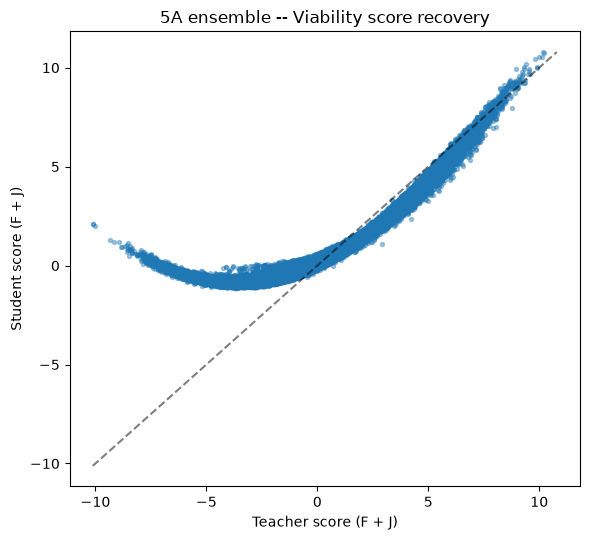

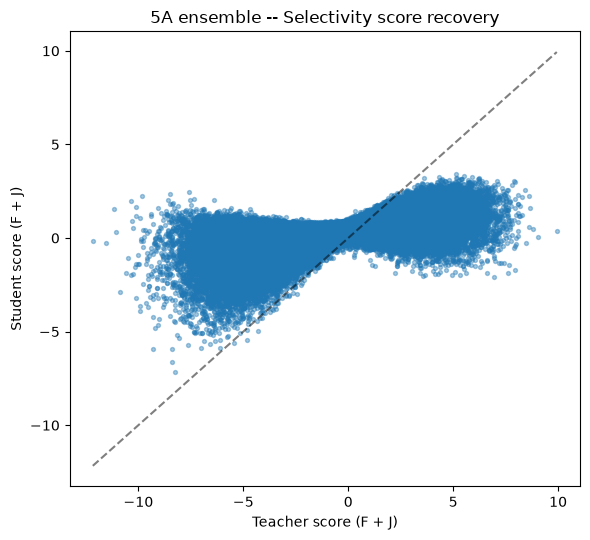

In [11]:
F_viab_hats_A, J_viab_hats_A, F_sel_hats_A, J_sel_hats_A = [], [], [], []
for i, (m_v, m_s) in enumerate(zip(models_viab_A, models_sel_A), start=1):
    Fv, Jv = extract_effective_FJ(m_v, protocol._T_viab, backgrounds)
    Fs, Js = extract_effective_FJ(m_s, protocol._T_sel,  backgrounds)
    F_viab_hats_A.append(Fv); J_viab_hats_A.append(Jv)
    F_sel_hats_A.append(Fs);  J_sel_hats_A.append(Js)

print("[5A] Per-protocol independent models:")
for i in range(5):
    sv_hat = np.array(protocol.compute_score(F_viab_hats_A[i], J_viab_hats_A[i]))
    ss_hat = np.array(protocol.compute_score(F_sel_hats_A[i],  J_sel_hats_A[i]))
    shrinkage_diagnostic(f"  viab  #{i+1}", score_viab_gt, sv_hat)
    shrinkage_diagnostic(f"  sel   #{i+1}", score_sel_gt,  ss_hat)

# Ensemble = plain average of the 5 independent recoveries.
F_viab_hat_A = np.mean(F_viab_hats_A, axis=0)
J_viab_hat_A = np.mean(J_viab_hats_A, axis=0)
F_sel_hat_A  = np.mean(F_sel_hats_A,  axis=0)
J_sel_hat_A  = np.mean(J_sel_hats_A,  axis=0)

score_viab_hat_A = np.array(protocol.compute_score(F_viab_hat_A, J_viab_hat_A))
score_sel_hat_A  = np.array(protocol.compute_score(F_sel_hat_A,  J_sel_hat_A))
combined_gt_A    = score_viab_gt     / protocol._T_viab + score_sel_gt     / protocol._T_sel
combined_hat_A   = score_viab_hat_A  / protocol._T_viab + score_sel_hat_A  / protocol._T_sel

print("\n[5A] Ensemble (average of the 5):")
shrinkage_diagnostic("  viab  ensemble", score_viab_gt, score_viab_hat_A)
shrinkage_diagnostic("  sel   ensemble", score_sel_gt,  score_sel_hat_A)
print(f"  precision@1%  : {precision_at_k(combined_gt_A, combined_hat_A, k_frac=0.01):.4f}")
print(f"  precision@10% : {precision_at_k(combined_gt_A, combined_hat_A, k_frac=0.10):.4f}")

_ = plot_score_teacher_vs_student(score_viab_gt, score_viab_hat_A, title="5A ensemble -- Viability score recovery")
_ = plot_score_teacher_vs_student(score_sel_gt,  score_sel_hat_A,  title="5A ensemble -- Selectivity score recovery")

### 5B. Sequential retraining -- one model, carried across protocol_1 -> protocol_5

Same `train_profile_mlp`, but `model=` is passed from one call to the next: the network
weights survive across phases, only the optimizer (Adam moments + a fresh warmup-cosine
schedule sized to that phase's data) resets each time. So the final model has been fitted on
each protocol's own train/val split in turn, not on one big shuffled pool.

In [12]:
model_viab_B, model_sel_B = None, None

for i, (sv, yv, ss, ys) in enumerate(datasets, start=1):
    if i == 5:
        break
    Xv, Xs = build_profile_features(sv), build_profile_features(ss)
    Xtr_v, ytr_v, Xva_v, yva_v = split_train_val(Xv, yv)
    Xtr_s, ytr_s, Xva_s, yva_s = split_train_val(Xs, ys)

    model_viab_B, _ = train_profile_mlp(Xtr_v, ytr_v, Xva_v, yva_v, seed=0, verbose=False, model=model_viab_B)
    model_sel_B,  _ = train_profile_mlp(Xtr_s, ytr_s, Xva_s, yva_s, seed=0, verbose=False, model=model_sel_B)

    # Checkpoint metrics after each phase, to see whether the model improves monotonically
    # as it sees more protocols or oscillates/forgets earlier ones.
    Fv, Jv = extract_effective_FJ(model_viab_B, protocol._T_viab, backgrounds)
    Fs, Js = extract_effective_FJ(model_sel_B,  protocol._T_sel,  backgrounds)
    sv_hat = np.array(protocol.compute_score(Fv, Jv))
    ss_hat = np.array(protocol.compute_score(Fs, Js))
    print(f"[5B] after protocol {i}:")
    shrinkage_diagnostic(f"  viab  (thru #{i})", score_viab_gt, sv_hat)
    shrinkage_diagnostic(f"  sel   (thru #{i})", score_sel_gt,  ss_hat)

[5B] after protocol 1:
  viab  (thru #1)     r=0.918  slope(hat~gt)=0.567  std(hat)/std(gt)=0.617
  sel   (thru #1)     r=0.743  slope(hat~gt)=0.235  std(hat)/std(gt)=0.316
[5B] after protocol 2:
  viab  (thru #2)     r=0.930  slope(hat~gt)=0.571  std(hat)/std(gt)=0.614
  sel   (thru #2)     r=0.731  slope(hat~gt)=0.227  std(hat)/std(gt)=0.311
[5B] after protocol 3:
  viab  (thru #3)     r=0.927  slope(hat~gt)=0.556  std(hat)/std(gt)=0.599
  sel   (thru #3)     r=0.729  slope(hat~gt)=0.218  std(hat)/std(gt)=0.299
[5B] after protocol 4:
  viab  (thru #4)     r=0.928  slope(hat~gt)=0.565  std(hat)/std(gt)=0.609
  sel   (thru #4)     r=0.728  slope(hat~gt)=0.217  std(hat)/std(gt)=0.298


### 5B. Final model (after all 5 protocols) -- recovery + plots

[5B] Final model (after protocol_1..protocol_5):
  viab  final         r=0.928  slope(hat~gt)=0.565  std(hat)/std(gt)=0.609
  sel   final         r=0.728  slope(hat~gt)=0.217  std(hat)/std(gt)=0.298
  precision@1%  : 0.5650
  precision@10% : 0.7165


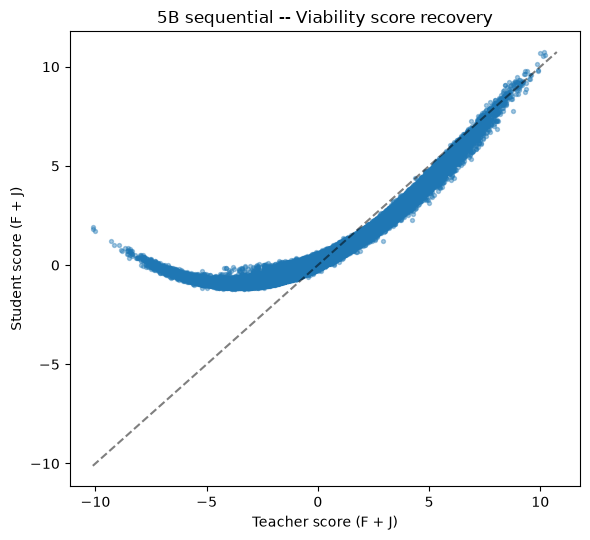

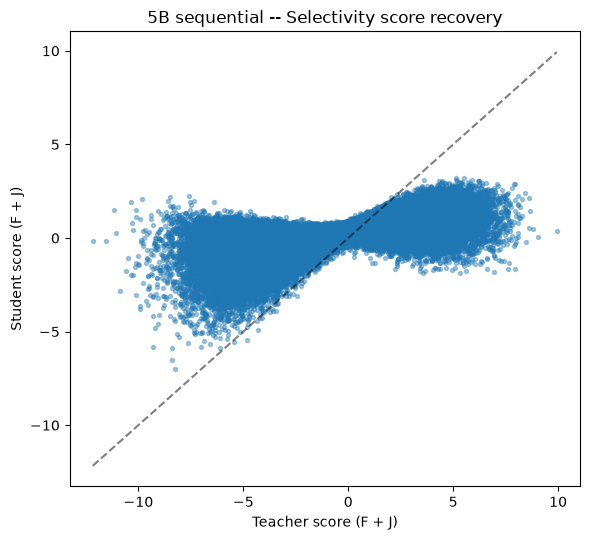

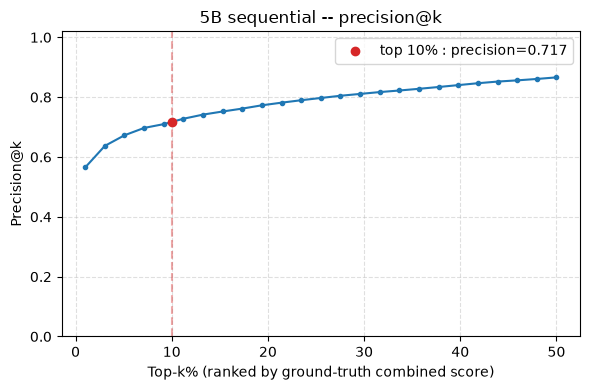

In [13]:
F_viab_hat_B, J_viab_hat_B = extract_effective_FJ(model_viab_B, protocol._T_viab, backgrounds)
F_sel_hat_B,  J_sel_hat_B  = extract_effective_FJ(model_sel_B,  protocol._T_sel,  backgrounds)

score_viab_hat_B = np.array(protocol.compute_score(F_viab_hat_B, J_viab_hat_B))
score_sel_hat_B  = np.array(protocol.compute_score(F_sel_hat_B,  J_sel_hat_B))
combined_gt_B    = score_viab_gt    / protocol._T_viab + score_sel_gt    / protocol._T_sel
combined_hat_B   = score_viab_hat_B / protocol._T_viab + score_sel_hat_B / protocol._T_sel

print("[5B] Final model (after protocol_1..protocol_5):")
shrinkage_diagnostic("  viab  final", score_viab_gt, score_viab_hat_B)
shrinkage_diagnostic("  sel   final", score_sel_gt,  score_sel_hat_B)
print(f"  precision@1%  : {precision_at_k(combined_gt_B, combined_hat_B, k_frac=0.01):.4f}")
print(f"  precision@10% : {precision_at_k(combined_gt_B, combined_hat_B, k_frac=0.10):.4f}")

_ = plot_score_teacher_vs_student(score_viab_gt, score_viab_hat_B, title="5B sequential -- Viability score recovery")
_ = plot_score_teacher_vs_student(score_sel_gt,  score_sel_hat_B,  title="5B sequential -- Selectivity score recovery")
plot_precision_at_k(combined_gt_B, combined_hat_B, title="5B sequential -- precision@k")

## 6. Comparison: 5A ensemble vs 5B sequential

In [14]:
summary = pd.DataFrame([
    dict(strategy="5A ensemble (avg of 5 independent)",
         r_viab=pearson(score_viab_gt, score_viab_hat_A),
         r_sel=pearson(score_sel_gt, score_sel_hat_A),
         precision_1pct=precision_at_k(combined_gt_A, combined_hat_A, k_frac=0.01),
         precision_10pct=precision_at_k(combined_gt_A, combined_hat_A, k_frac=0.10)),
    dict(strategy="5B sequential (1 model thru all 5)",
         r_viab=pearson(score_viab_gt, score_viab_hat_B),
         r_sel=pearson(score_sel_gt, score_sel_hat_B),
         precision_1pct=precision_at_k(combined_gt_B, combined_hat_B, k_frac=0.01),
         precision_10pct=precision_at_k(combined_gt_B, combined_hat_B, k_frac=0.10)),
])
summary

,strategy,r_viab,r_sel,precision_1pct,precision_10pct
0,5A ensemble (avg of 5 independent),0.924131,0.725275,0.5635,0.7184
1,5B sequential (1 model thru all 5),0.928316,0.727965,0.5650,0.7165
